In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/Ev_charging_data

2023  2024  2025


In [3]:
import pandas as pd
import glob

base_path = "/content/drive/MyDrive/Ev_charging_data"

files = (
    glob.glob(f"{base_path}/2023/*.csv") +
    glob.glob(f"{base_path}/2024/*.csv") +
    glob.glob(f"{base_path}/2025/*.csv")
)

print("Number of files loaded:", len(files))


Number of files loaded: 36


In [4]:
#Add month & year from filename and combine
all_dfs = []

for file in files:
    df = pd.read_csv(file)

    filename = file.split("/")[-1]
    month, year = filename.replace(".csv","").split("_")

    df['month'] = int(month)
    df['year'] = int(year)

    all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)

EDA(Exploratory data amalysis)

In [5]:
master_df[['year','month']].drop_duplicates().sort_values(['year','month'])


,year,month
0,2023,1
90,2023,2
182,2023,3
282,2023,4
390,2023,5
513,2023,6
641,2023,7
774,2023,8
919,2023,9
1078,2023,10


In [6]:
#DATA QUALITY CHECK & CLEANING
master_df.info()
master_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9018 entries, 0 to 9017
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   circle         9018 non-null   object 
 1   division       9018 non-null   object 
 2   subdivision    9018 non-null   object 
 3   section        9018 non-null   object 
 4   area           9018 non-null   object 
 5   catdesc        9018 non-null   object 
 6   catcode        9018 non-null   int64  
 7   totservices    9018 non-null   int64  
 8   billdservices  8608 non-null   float64
 9   units          9018 non-null   float64
 10  load           9018 non-null   float64
 11  month          9018 non-null   int64  
 12  year           9018 non-null   int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 916.0+ KB


,catcode,totservices,billdservices,units,load,month,year
count,9018.0,9018.000000,8608.000000,9018.000000,9018.000000,9018.000000,9018.000000
mean,9.0,1.236416,1.226185,1855.061654,45.154376,6.977711,2024.348858
std,0.0,0.586337,0.568592,3444.393799,37.736167,3.374856,0.764240
min,9.0,1.000000,1.000000,-1740.000000,2.000000,1.000000,2023.000000
25%,9.0,1.000000,1.000000,3.000000,17.000000,4.000000,2024.000000
50%,9.0,1.000000,1.000000,465.000000,50.000000,7.000000,2025.000000
75%,9.0,1.000000,1.000000,2329.750000,54.000000,10.000000,2025.000000
max,9.0,6.000000,6.000000,43562.000000,336.000000,12.000000,2025.000000


In [7]:
# Remove negative consumption
master_df = master_df[master_df['units'] >= 0]

# Replace zero services to avoid division error
master_df['billdservices'] = master_df['billdservices'].replace(0, 1)

# Fill missing load with median
master_df['load'] = master_df['load'].fillna(master_df['load'].median())


In [8]:
#REMOVE INVALID RECORDS(Records with zero consumption, zero services, or zero connected load were removed to avoid invalid utilization ratios and misleading demand estimates.)
# Remove invalid rows
master_df = master_df[
    (master_df['units'] > 0) &
    (master_df['billdservices'] > 0) &
    (master_df['load'] > 0)
].reset_index(drop=True)


In [9]:
#OUTLIER HANDLING USING IQR
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

In [10]:
#Applying it to key numerical columns
for col in ['units', 'billdservices', 'load']:
    master_df = cap_outliers_iqr(master_df, col)

In [11]:
#Remove rows with suspicious utilization
# Preliminary utilization check
master_df['temp_util'] = master_df['units'] / master_df['load']

master_df = master_df[
    (master_df['temp_util'] > 0) &
    (master_df['temp_util'] < master_df['temp_util'].quantile(0.99))
]

master_df.drop(columns=['temp_util'], inplace=True)


In [12]:
master_df.describe()

,catcode,totservices,billdservices,units,load,month,year
count,6876.0,6876.000000,6876.0,6876.000000,6876.000000,6876.000000,6876.000000
mean,9.0,1.273560,1.0,1987.476840,43.543016,6.926702,2024.303810
std,0.0,0.635945,0.0,2245.587325,30.104122,3.413919,0.764326
min,9.0,1.000000,1.0,1.000000,2.000000,1.000000,2023.000000
25%,9.0,1.000000,1.0,213.000000,18.000000,4.000000,2024.000000
50%,9.0,1.000000,1.0,1081.000000,45.000000,7.000000,2024.000000
75%,9.0,1.000000,1.0,2959.500000,54.000000,10.000000,2025.000000
max,9.0,6.000000,1.0,7263.250000,108.000000,12.000000,2025.000000


In [13]:
#CREATE DERIVED METRICS
master_df['units_per_service'] = master_df['units'] / master_df['billdservices']
master_df['load_utilization'] = master_df['units'] / master_df['load']


In [14]:
#COMBINING YEAR-WISE DATA (FOR ANALYSIS)
yearly_demand = master_df.groupby('year')['units'].sum().reset_index()
yearly_demand

,year,units
0,2023,1267898.00
1,2024,4052619.75
2,2025,8345373.00


In [15]:
#Year + Month-wise demand (time series)
monthly_demand = master_df.groupby(['year','month'])['units'].sum().reset_index()


In [16]:
#Year + Division-wise demand
year_division_demand = master_df.groupby(['year','division'])['units'].sum().reset_index()


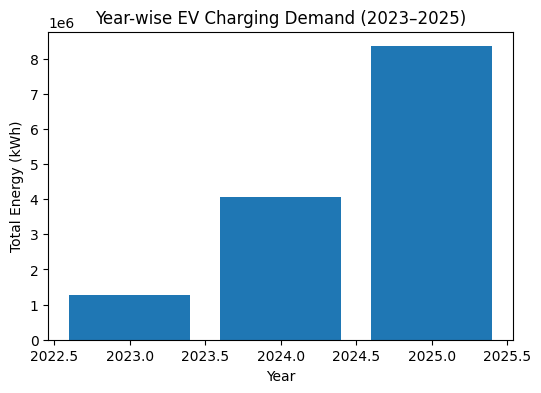

In [17]:
#Year-wise demand trend
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(yearly_demand['year'], yearly_demand['units'])
plt.xlabel("Year")
plt.ylabel("Total Energy (kWh)")
plt.title("Year-wise EV Charging Demand (2023–2025)")
plt.show()


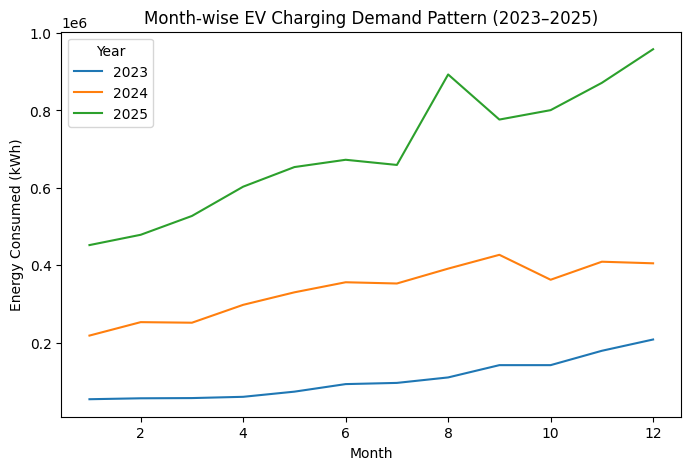

In [18]:
#Month-wise demand pattern
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for year in monthly_demand['year'].unique():
    data = monthly_demand[monthly_demand['year'] == year]
    plt.plot(data['month'], data['units'], label=str(year))

plt.xlabel("Month")
plt.ylabel("Energy Consumed (kWh)")
plt.title("Month-wise EV Charging Demand Pattern (2023–2025)")
plt.legend(title="Year")
plt.show()


In [19]:
#Area-wise demand
area_demand = master_df.groupby('division')['units'].sum().reset_index()

In [20]:
area_demand.sort_values('units', ascending=False)



,division,units
10,GACHIBOWLI,1160051.25
38,SAROORNAGAR,1046765.00
36,SAINIKPURI,868575.75
2,BANJARA HILLS,793252.75
14,HABSIGUDA,764347.25
24,KUKATPALLY,705052.50
23,KONDAPUR,574106.50
34,RAJENDRA NAGAR,573801.50
35,SAIFABAD,556997.50
32,PARADISE,508516.50


In [21]:
circle_demand = master_df.groupby('circle')['units'].sum().reset_index()
circle_demand

,circle,units
0,BANJARA HILLS,1238883.50
1,CYBERCITY,1962105.25
2,GADWAL,146786.50
3,HABSIGUDA,1651230.00
4,HYDERABAD CENTRAL,1089784.25
5,HYDERABAD SOUTH,430170.25
6,MAHABOOBNAGAR,350071.25
7,MEDAK,22062.00
8,MEDCHAL,1284400.25
9,NAGARKURNOOL,129357.25


In [22]:
subdivision_demand = master_df.groupby('subdivision')['units'].sum().reset_index()
subdivision_demand

,subdivision,units
0,A S RAO NAGAR,342530.50
1,A.C.GUARDS,19424.00
2,ACHAMPET,30679.00
3,ALAMPUR X ROAD,146786.50
4,ALER,19.00
...,...,...
102,UPPAL,343701.25
103,VANASTHALIPURAM,315624.00
104,VEMULAPALLY,23602.00
105,WANAPARTHY,262.00


DIAGNOSTIC ANALYTICS

In [23]:
master_df[['units', 'load']].corr()


,units,load
units,1.000000,0.424263
load,0.424263,1.000000


In [24]:
#STATION / AREA CLASSIFICATION
q1 = master_df['units'].quantile(0.25)
q3 = master_df['units'].quantile(0.75)

def classify(u):
    if u > q3:
        return "High Demand"
    elif u < q1:
        return "Low Demand"
    else:
        return "Moderate Demand"

master_df['demand_category'] = master_df['units'].apply(classify)
master_df

,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,month,year,units_per_service,load_utilization,demand_category
0,BANJARA HILLS,GREEN LANDS,GREENLANDS,BEGUMPET,GRC. SHYAMLAL,EV CHARGING STATIONS,9,1,1.0,1246.00,22.0,1,2023,1246.00,56.636364,Moderate Demand
1,BANJARA HILLS,GREEN LANDS,GREENLANDS,GREENLANDS,GRC HV GREENLANDS,EV CHARGING STATIONS,9,1,1.0,227.00,10.0,1,2023,227.00,22.700000,Moderate Demand
2,BANJARA HILLS,BANJARA HILLS,AMEERPET,YOUSUFGUDA,PRAGATHINAGAR-1,EV CHARGING STATIONS,9,1,1.0,216.00,8.0,1,2023,216.00,27.000000,Moderate Demand
3,BANJARA HILLS,BANJARA HILLS,BANJARA HILLS,FILM NAGAR,"CHURCH GULLY,MLA COLONY,APOLO",EV CHARGING STATIONS,9,1,1.0,1282.00,55.0,1,2023,1282.00,23.309091,Moderate Demand
4,BANJARA HILLS,BANJARA HILLS,JUBILEE HILLS,JUBILEE HILLS,GRC HIGH VALUES,EV CHARGING STATIONS,9,1,1.0,31.00,15.0,1,2023,31.00,2.066667,Low Demand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6941,YADADRI,CHOUTUPPAL,CHOUTUPPAL,CHOUTUPPAL,TOOFRAN PET,EV CHARGING STATIONS,9,2,1.0,203.00,108.0,12,2025,203.00,1.879630,Low Demand
6942,YADADRI,BHONGIR,BHONGIR,BHONGIR _ RURAL,RAIGIR,EV CHARGING STATIONS,9,5,1.0,7263.25,108.0,12,2025,7263.25,67.252315,High Demand
6943,YADADRI,BHONGIR,BHONGIR,BHONGIR _ RURAL,WADAIGUDEM,EV CHARGING STATIONS,9,1,1.0,435.00,55.0,12,2025,435.00,7.909091,Moderate Demand
6944,YADADRI,BHONGIR,BHONGIR,BHONGIR - TOWN,BHONGIR(T),EV CHARGING STATIONS,9,1,1.0,1144.00,54.0,12,2025,1144.00,21.185185,Moderate Demand



GROWING DEMAND PREDICTION

In [25]:
#DEMAND FORECASTING (HOLT–WINTERS)
# Create proper date column
master_df['date'] = pd.to_datetime(
    master_df['year'].astype(str) + '-' +
    master_df['month'].astype(str) + '-01'
)

# Aggregate to monthly demand (state-level)
monthly_demand = (
    master_df
    .groupby('date')['units']
    .sum()
    .reset_index()
    .sort_values('date')
)

monthly_demand.set_index('date', inplace=True)
monthly_demand.head()


,units
date,
2023-01-01,53627.00
2023-02-01,56018.00
2023-03-01,56586.00
2023-04-01,59854.00
2023-05-01,73193.25


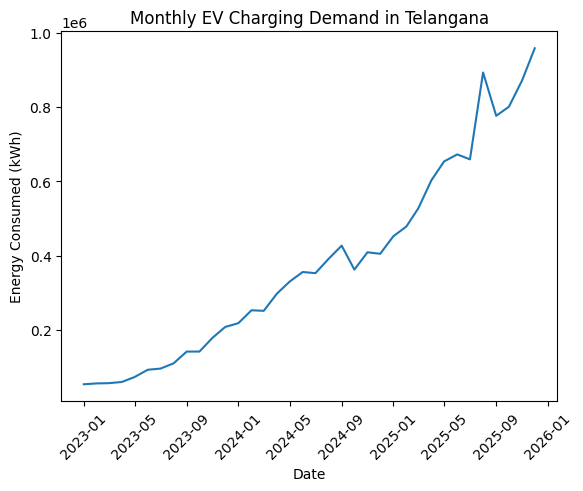

In [26]:
#Visualize historical demand
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_demand.index, monthly_demand['units'])
plt.title('Monthly EV Charging Demand in Telangana')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumed (kWh)')
plt.show()


In [27]:
#rain Holt–Winters Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    monthly_demand['units'],
    trend='add',
    seasonal=None
)

hw_fit = hw_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [28]:
import numpy as np
import pandas as pd
import os

def dynamic_planning(target_year, target_month, division_name=None):

    # ================================
    # 1️⃣ DATE VALIDATION
    # ================================

    last_date = monthly_demand.index.max()

    try:
        target_date = pd.Timestamp(year=target_year, month=target_month, day=1)
    except:
        print("❌ Invalid date.")
        return

    months_ahead = (target_date.year - last_date.year) * 12 + \
                   (target_date.month - last_date.month)

    if months_ahead <= 0:
        print(f"⚠️ Please enter a future date after {last_date.strftime('%Y-%m')}")
        return

    # ================================
    # 2️⃣ FORECAST DEMAND (CORRECTED)
    # ================================

    forecast = hw_fit.forecast(months_ahead)

    # 🔴 FIX: Use PEAK monthly demand (not sum)
    peak_monthly_demand = forecast.max()

    # ================================
    # 3️⃣ DIVISION DEMAND ALLOCATION
    # ================================

    temp_df = area_df.copy()

    # Allocate proportionally
    temp_df['future_demand'] = (
        temp_df['units'] / temp_df['units'].sum()
    ) * peak_monthly_demand

    # ================================
    # 4️⃣ INFRASTRUCTURE LOGIC (REALISTIC)
    # ================================
    # ================================
    # 4️⃣ IMPROVED INFRASTRUCTURE LOGIC
# ================================

    EV_GROWTH_FACTOR = 1 + (months_ahead * 0.02)
    AVG_STATION_CAPACITY = 30000
    TARGET_UTILIZATION = 0.65
    EV_STATION_RATIO = 0.01
    TARIFF = 6
    # Apply growth
    temp_df['future_demand_growth_adjusted'] = (
    temp_df['future_demand'] * EV_GROWTH_FACTOR
     )

    # Required stations
    temp_df['required_stations'] = (
    temp_df['future_demand_growth_adjusted'] /
    (AVG_STATION_CAPACITY * TARGET_UTILIZATION)
    ).apply(np.ceil)

    # Current realistic EV stations
    temp_df['current_stations'] = (
    temp_df['billdservices'] * EV_STATION_RATIO
    ).apply(np.ceil)

    # Additional stations
    temp_df['additional_stations_required'] = (
    temp_df['required_stations'] -
    temp_df['current_stations']
    ).clip(lower=0)

    # Revenue
    temp_df['projected_revenue'] = (
    temp_df['future_demand_growth_adjusted'] * TARIFF
    )


    # ================================
    # 5️⃣ RANDOM FOREST PREDICTION
    # ================================
    # Corrected: Use 'future_demand_growth_adjusted' for dynamic prediction
    temp_df['effective_future_demand_static'] = temp_df['future_demand_growth_adjusted']
    X_new = temp_df[['effective_future_demand_static', 'load_utilization']]
    X_new_scaled = scaler.transform(X_new)

    temp_df['profit_probability'] = rf.predict_proba(X_new_scaled)[:, 1]

    # ================================
    # 6️⃣ TELANGANA SUMMARY
    # ================================

    total_required = temp_df['required_stations'].sum()
    total_current = temp_df['current_stations'].sum()
    total_additional = max(total_required - total_current, 0)
    total_revenue = temp_df['projected_revenue'].sum()

    print(f"\n📅 Planning till: {target_date.strftime('%B %Y')}")
    print(f"Forecast Horizon: {months_ahead} months\n")

    print("🔵 TELANGANA SUMMARY")
    print("----------------------------")
    print(f"Peak Monthly Demand (kWh): {round(peak_monthly_demand,2)}")
    print(f"Total Required Stations: {int(total_required)}")
    print(f"Total Additional Stations Needed: {int(total_additional)}")
    print(f"Total Projected Revenue (₹): {round(total_revenue,2)}")

    # ================================
    # 7️⃣ DIVISION LEVEL (OPTIONAL)
    # ================================

    if division_name and division_name.strip() != "":
        division_name_cleaned = division_name.strip().lower()
        # The check for division existence can still be done here before calling generate_advanced_dashboard

        division_exists = division_name_cleaned in temp_df['division'].str.lower().values

        if not division_exists:
            print("❌ Division not found.")
            return

        division_result = temp_df[temp_df['division'].str.lower() == division_name_cleaned]

        print(f"\n🔹 DIVISION SUMMARY ({division_result['division'].values[0]})")
        print("--------------------------------------")

        display_df = division_result[[
            'division',
            'additional_stations_required',
            'projected_revenue',
            'profit_probability'
        ]]

        # Pass the full temp_df for state-level calculations AND the specific division name for filtering
        generate_advanced_dashboard(temp_df, target_date, division_name_cleaned)

        return display_df # Still return for display(result)

    # If no division specified → generate Telangana page only
    generate_advanced_dashboard(temp_df, target_date) # Pass the full temp_df

In [29]:
import plotly.express as px
import plotly.graph_objects as go
import os

def generate_advanced_dashboard(all_divisions_df, target_date, selected_division_name=None):

    folder = "dynamic_reports"
    os.makedirs(folder, exist_ok=True)

    # ==============================
    # 🔵 STATE LEVEL CALCULATIONS
    # ==============================

    total_required = all_divisions_df['required_stations'].sum()
    total_current = all_divisions_df['current_stations'].sum()
    total_additional = all_divisions_df['additional_stations_required'].sum()
    total_revenue = all_divisions_df['projected_revenue'].sum()

    # ==============================
    # 1️⃣ STATE COMPARISON CHART
    # ==============================

    fig_state_compare = go.Figure(data=[
        go.Bar(name='Existing Stations', x=['Telangana'], y=[total_current]),
        go.Bar(name='Required Stations', x=['Telangana'], y=[total_required])
    ])

    fig_state_compare.update_layout(
        barmode='group',
        title='Existing vs Required Stations (Telangana)',
        template='plotly_white'
    )

    # ==============================
    # 2️⃣ TOP DIVISIONS CHART
    # ==============================

    top_divisions = all_divisions_df.sort_values(
        by='additional_stations_required',
        ascending=False
    ).head(10)

    fig_top_div = px.bar(
        top_divisions,
        x='division',
        y='additional_stations_required',
        title='Top 10 Divisions – Additional Stations Required',
        color='additional_stations_required',
        color_continuous_scale='Blues'
    )

    fig_top_div.update_layout(
        xaxis_tickangle=-45,
        template='plotly_white'
    )

    # ==============================
    # 3️⃣ STATE DASHBOARD HTML
    # ==============================

    state_html = f"""
    <html>
    <head>
        <title>State Dashboard</title>
        <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
        <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css">
    </head>
    <body class="container mt-4">

    <h1 class="text-center mb-4">
        Telangana Infrastructure Planning - {target_date.strftime('%B %Y')}
    </h1>

    <div class="row text-center mb-4">
        <div class="col-md-3">
            <div class="card bg-light">
                <div class="card-body">
                    <h5>Total Required</h5>
                    <h3>{int(total_required)}</h3>
                </div>
            </div>
        </div>

        <div class="col-md-3">
            <div class="card bg-light">
                <div class="card-body">
                    <h5>Existing</h5>
                    <h3>{int(total_current)}</h3>
                </div>
            </div>
        </div>

        <div class="col-md-3">
            <div class="card bg-light">
                <div class="card-body">
                    <h5>Additional Needed</h5>
                    <h3>{int(total_additional)}</h3>
                </div>
            </div>
        </div>

        <div class="col-md-3">
            <div class="card bg-light">
                <div class="card-body">
                    <h5>Total Revenue (₹)</h5>
                    <h3>{round(total_revenue,2)}</h3>
                </div>
            </div>
        </div>
    </div>

    {fig_state_compare.to_html(full_html=False)}
    <hr>
    {fig_top_div.to_html(full_html=False)}

    </body>
    </html>
    """

    with open(f"{folder}/State_Dashboard.html", "w", encoding="utf-8") as f:
        f.write(state_html)

    # ==============================
    # 4️⃣ DIVISION DASHBOARD
    # ==============================

    if selected_division_name and selected_division_name.strip() != "":

        division_df = all_divisions_df[all_divisions_df['division'].str.lower() == \
                         selected_division_name.strip().lower()]

        if len(division_df) > 0:

            div = division_df.iloc[0]

            fig_div_compare = go.Figure(data=[
                go.Bar(name='Division Required',
                       x=[div['division']],
                       y=[div['required_stations']]),
                go.Bar(name='Telangana Required',
                       x=['Telangana'],
                       y=[total_required])
            ])

            fig_div_compare.update_layout(
                barmode='group',
                title='Division vs Telangana Required Stations',
                template='plotly_white'
            )

            fig_profit = go.Figure(go.Indicator(
                mode="gauge+number",
                value=div['profit_probability'] * 100,
                title={'text': "Profit Probability (%)"},
                gauge={'axis': {'range': [0, 100]}}
            ))

            division_html = f"""
            <html>
            <head>
                <title>Division Dashboard</title>
                <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
                <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css">
            </head>
            <body class="container mt-4">

            <h1 class="text-center mb-4">
                Division Analysis - {div['division']} ({target_date.strftime('%B %Y')})
            </h1>

            {fig_div_compare.to_html(full_html=False)}
            <hr>
            {fig_profit.to_html(full_html=False)}

            </body>
            </html>
            """

            with open(f"{folder}/Division_Dashboard.html", "w", encoding="utf-8") as f:
                f.write(division_html)

    print("✅ Advanced Interactive Dashboards Generated!")


Enter target year: 2028
Enter target month (1-12): 5


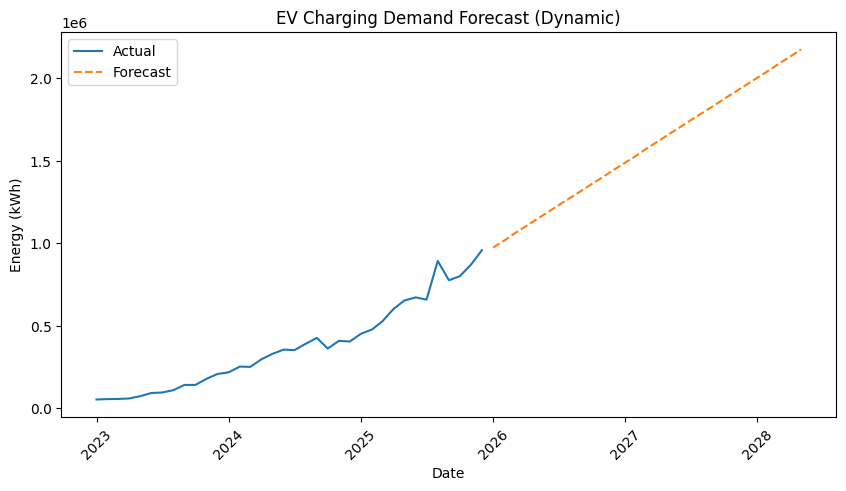

In [43]:
future_year = int(input("Enter target year: "))
future_month = int(input("Enter target month (1-12): "))

last_date = monthly_demand.index.max()
target_date = pd.Timestamp(year=future_year, month=future_month, day=1)

months_ahead = (target_date.year - last_date.year) * 12 + \
               (target_date.month - last_date.month)

if months_ahead <= 0:
    print(f"⚠️ Please enter a future date after {last_date.strftime('%Y-%m')}")
else:
    forecast = hw_fit.forecast(months_ahead)

    forecast_dates = pd.date_range(
        start=last_date + pd.offsets.MonthBegin(),
        periods=months_ahead,
        freq='MS'
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(monthly_demand.index, monthly_demand['units'], label='Actual')
    plt.plot(forecast_dates, forecast, label='Forecast', linestyle='--')

    plt.title("EV Charging Demand Forecast (Dynamic)")
    plt.xlabel("Date")
    plt.ylabel("Energy (kWh)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

In [31]:
#Model Evaluation using MAPE
from sklearn.metrics import mean_absolute_percentage_error
test_horizon = 3

train = monthly_demand.iloc[:-test_horizon]['units']
test  = monthly_demand.iloc[-test_horizon:]['units']


hw_eval_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
).fit()
test_forecast = hw_eval_model.forecast(test_horizon)


mape = mean_absolute_percentage_error(test, test_forecast) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 6.49%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [32]:
for h in [3, 6, 9]:
    train = monthly_demand.iloc[:-h]['units']
    test  = monthly_demand.iloc[-h:]['units']

    model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal=None
    ).fit()

    forecast = model.forecast(h)

    mape = mean_absolute_percentage_error(test, forecast) * 100
    print(f"{h}-Month Horizon MAPE: {mape:.2f}%")


3-Month Horizon MAPE: 6.49%
6-Month Horizon MAPE: 6.16%
9-Month Horizon MAPE: 19.91%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


PHASE 3

In [33]:
#DIVISION-LEVEL AGGREGATION
area_df = master_df.groupby('division').agg({
    'units': 'sum',
    'billdservices': 'sum',
    'load': 'mean'
}).reset_index()

area_df.head()

,division,units,billdservices,load
0,ASMANGADH,99286.00,50.0,35.560000
1,AZAMABAD,115059.00,98.0,41.275510
2,BANJARA HILLS,793252.75,271.0,51.505535
3,BEGUM BAZAR,106828.00,82.0,32.731707
4,BHONGIR,227567.25,101.0,70.930693


In [34]:
#CORE INDICATORS
# Current demand intensity
area_df['demand_per_service'] = area_df['units'] / area_df['billdservices']

# Grid stress indicator
area_df['load_utilization'] = area_df['units'] / area_df['load']

In [35]:
#MACHINE LEARNING (RANDOM FOREST)
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [36]:
# =========================================
# CREATE STATIC INFRASTRUCTURE FEATURES
# (Aligned with new dynamic logic)
# =========================================

import numpy as np

PEAK_FACTOR = 1.2
AVG_STATION_CAPACITY = 30000
TARGET_UTILIZATION = 0.65
EV_STATION_RATIO = 0.01
TARIFF = 6

# Use CURRENT units as base
area_df['future_demand_static'] = area_df['units']

# Apply peak adjustment
area_df['effective_future_demand_static'] = (
    area_df['future_demand_static'] * PEAK_FACTOR
)

# Required stations (realistic logic)
area_df['required_stations_static'] = (
    area_df['effective_future_demand_static'] /
    (AVG_STATION_CAPACITY * TARGET_UTILIZATION)
).apply(np.ceil)

# Current EV stations (realistic assumption)
area_df['current_stations_static'] = (
    area_df['billdservices'] * EV_STATION_RATIO
).apply(np.ceil)

# Additional stations
area_df['additional_stations_static'] = (
    area_df['required_stations_static'] -
    area_df['current_stations_static']
).clip(lower=0)

# Revenue
area_df['estimated_revenue_static'] = (
    area_df['future_demand_static'] * TARIFF
)

# Profit label (binary)
profit_threshold = area_df['estimated_revenue_static'].median()

area_df['profit_feasible'] = (
    area_df['estimated_revenue_static'] >= profit_threshold
).astype(int)

In [37]:
# =========================================
# RANDOM FOREST TRAINING (FINAL VERSION)
# =========================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

# Final Feature Set (MUST match dynamic_planning)
X = area_df[['effective_future_demand_static', 'load_utilization']]
y = area_df['profit_feasible']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_scaled, y)

print("✅ Random Forest trained successfully with aligned infrastructure logic")

✅ Random Forest trained successfully with aligned infrastructure logic


In [38]:
print("Features used in RF:", X.columns.tolist())

Features used in RF: ['effective_future_demand_static', 'load_utilization']


In [45]:
future_year = int(input("Enter target year (e.g., 2027): "))
future_month = int(input("Enter target month (1-12): "))
division_name = input("Enter division name (or press Enter for state-level only): ")

result = dynamic_planning(future_year, future_month, division_name)

if result is not None:
    display(result)

Enter target year (e.g., 2027): 2028
Enter target month (1-12): 5
Enter division name (or press Enter for state-level only): banjara hills

📅 Planning till: May 2028
Forecast Horizon: 29 months

🔵 TELANGANA SUMMARY
----------------------------
Peak Monthly Demand (kWh): 2174822.01
Total Required Stations: 201
Total Additional Stations Needed: 109
Total Projected Revenue (₹): 20617312.66

🔹 DIVISION SUMMARY (BANJARA HILLS)
--------------------------------------
✅ Advanced Interactive Dashboards Generated!


,division,additional_stations_required,projected_revenue,profit_probability
2,BANJARA HILLS,8.0,1.196756e+06,0.4825
